# 08 - Analisis Feature Importance & Selection

## Objective
- Melatih model LightGBM secara cepat untuk mengestimasi feature importance.
- Mengidentifikasi fitur yang memiliki kontribusi rendah atau nol.
- Memilih top N fitur dengan gain tertinggi untuk modeling selanjutnya.
- Menyimpan peringkat feature importance ke folder metadata.

### Impor Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

data_path = Path('../data/processed/train_features.parquet')
if not data_path.exists():
    data_path = Path('../data/interim/train_merged.parquet')

train = pd.read_parquet(data_path)
print(f'Data loaded: {train.shape}')

Data loaded: (590540, 464)


### Persiapan Fitur & Split Data

In [ ]:
# Kolom yang tidak digunakan untuk modeling
exclude_cols = ['TransactionID', 'isFraud', 'TransactionDT']
object_cols = train.select_dtypes(include=['object']).columns.to_list()

# Pilih fitur numerik
feature_cols = [c for c in train.columns if c not in exclude_cols and c not in object_cols]

X = train[feature_cols]
y = train['isFraud']

# Pembagian train/val menggunakan stratifikasi agar fraud rate seimbang
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"feature : {len(feature_cols)}")
print(f"target : {y.sum():,} fraud / {len(y):,} total ({y.mean()*100:.2f}%)")

feature : 461
target : 20,663 fraud / 590,540 total (3.50%)


### Pelatihan Model LightGBM untuk Feature Importance

In [4]:
# Inisialisasi parameter model baseline
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 15,
    'max_depth' : 4,
    'learning_rate': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': -1,
    'random_state': 42
}

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

# Latih model dengan early stopping
evals_result = {}
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=20),
        lgb.record_evaluation(evals_result)
    ]
)

# Prediksi dan hitung skor AUC
y_pred = model.predict(X_val)
val_auc = roc_auc_score(y_val, y_pred)

print(f'\nbest iteration : {model.best_iteration}')
print(f'Validation AUC : {val_auc:.4f}')

Training until validation scores don't improve for 30 rounds
[20]	train's auc: 0.881938	valid's auc: 0.877364
[40]	train's auc: 0.892732	valid's auc: 0.887945
[60]	train's auc: 0.901356	valid's auc: 0.895775
[80]	train's auc: 0.908352	valid's auc: 0.901812
[100]	train's auc: 0.913285	valid's auc: 0.906097
[120]	train's auc: 0.916315	valid's auc: 0.90882
[140]	train's auc: 0.919782	valid's auc: 0.911303
[160]	train's auc: 0.922191	valid's auc: 0.913086
[180]	train's auc: 0.925548	valid's auc: 0.916048
[200]	train's auc: 0.927603	valid's auc: 0.917555
Did not meet early stopping. Best iteration is:
[200]	train's auc: 0.927603	valid's auc: 0.917555

best iteration : 200
Validation AUC : 0.9176


### Visualisasi: Learning Curve & ROC Curve

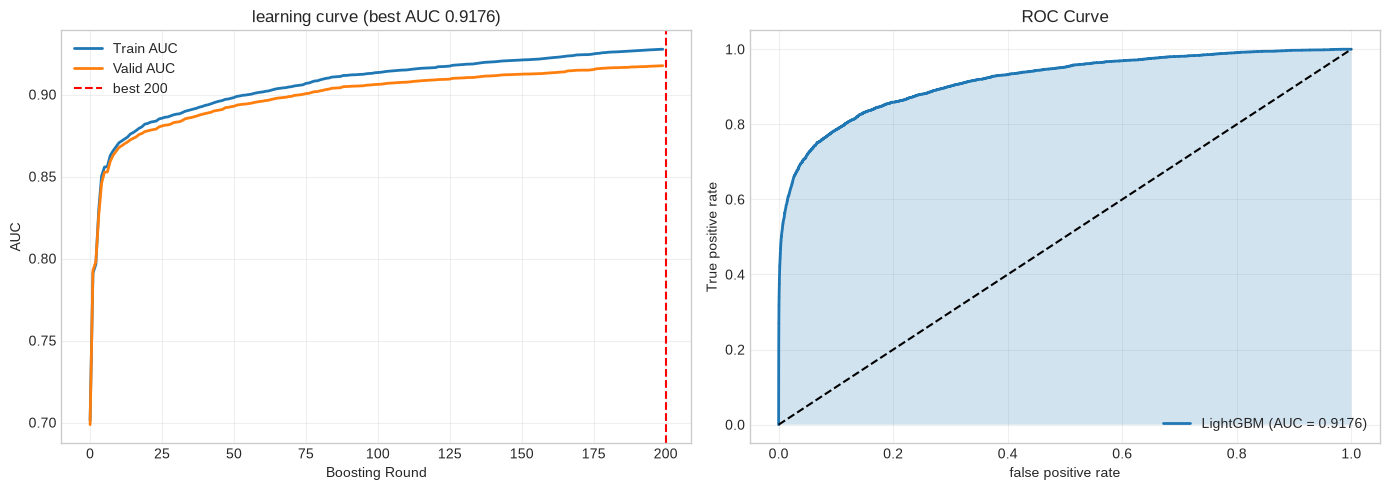

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot kurva pembelajaran (learning curve)
axes[0].plot(evals_result['train']['auc'], label='Train AUC', linewidth=2)
axes[0].plot(evals_result['valid']['auc'], label='Valid AUC', linewidth=2)
axes[0].axvline(x=model.best_iteration, color='r', linestyle='--', label=f'best {model.best_iteration}')
axes[0].set_xlabel("Boosting Round")
axes[0].set_ylabel('AUC')
axes[0].set_title(f'learning curve (best AUC {val_auc:.4f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot kurva ROC
fpr, tpr, _ = roc_curve(y_val, y_pred)
axes[1].plot(fpr, tpr, linewidth=2, label=f'LightGBM (AUC = {val_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].fill_between(fpr, tpr, alpha=0.2)
axes[1].set_xlabel('false positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Analisis: Hitung Nilai Feature Importance

In [6]:
# Hitung tingkat kepentingan fitur berdasarkan metrik gain
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print('Top 20 Features:')
print(importance.head(20).to_string(index=False))

Top 20 Features:
         feature   importance
            V257 39381.605665
             C14 19836.010471
      DeviceInfo 15994.819813
              C1 12790.289134
            V258 12731.651337
            V189  9547.243819
amt_vs_addr_mean  8341.391807
   R_emaildomain  8121.897495
             C13  7789.798686
            V317  6722.518855
              D2  6060.852687
             C12  5885.916570
            V308  5370.769196
  card1_amt_mean  5106.516551
             C11  4602.053885
              C8  4595.037296
            V266  4572.761515
            V294  4475.290592
           id_31  4339.842993
             V91  4327.739990


### Visualisasi: Top 30 Fitur Paling Berpengaruh

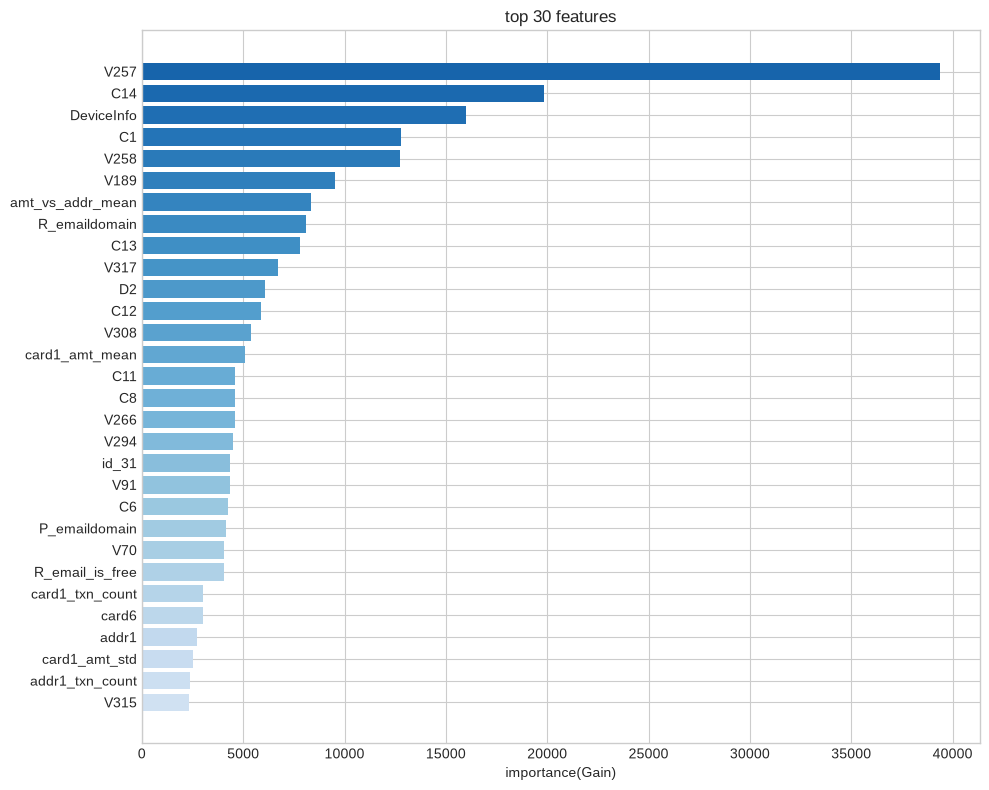

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
top30 = importance.head(30)
ax.barh(range(30),
        top30['importance'].values,
        color=plt.cm.Blues(np.linspace(0.8, 0.2, 30)))

ax.set_yticks(range(30))
ax.set_yticklabels(top30['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('importance(Gain)')
ax.set_title('top 30 features')
plt.tight_layout()
plt.show()

### Seleksi Fitur & Simpan Hasil

In [8]:
# Simpan seluruh daftar feature importance ke metadata
output_path = Path('../data/metadata')
output_path.mkdir(parents=True, exist_ok=True)
importance.to_csv(output_path / 'feature_importance.csv', index=False)

print(f'{output_path}')

../data/metadata
